Loading data from heatmap_dataset.npz...


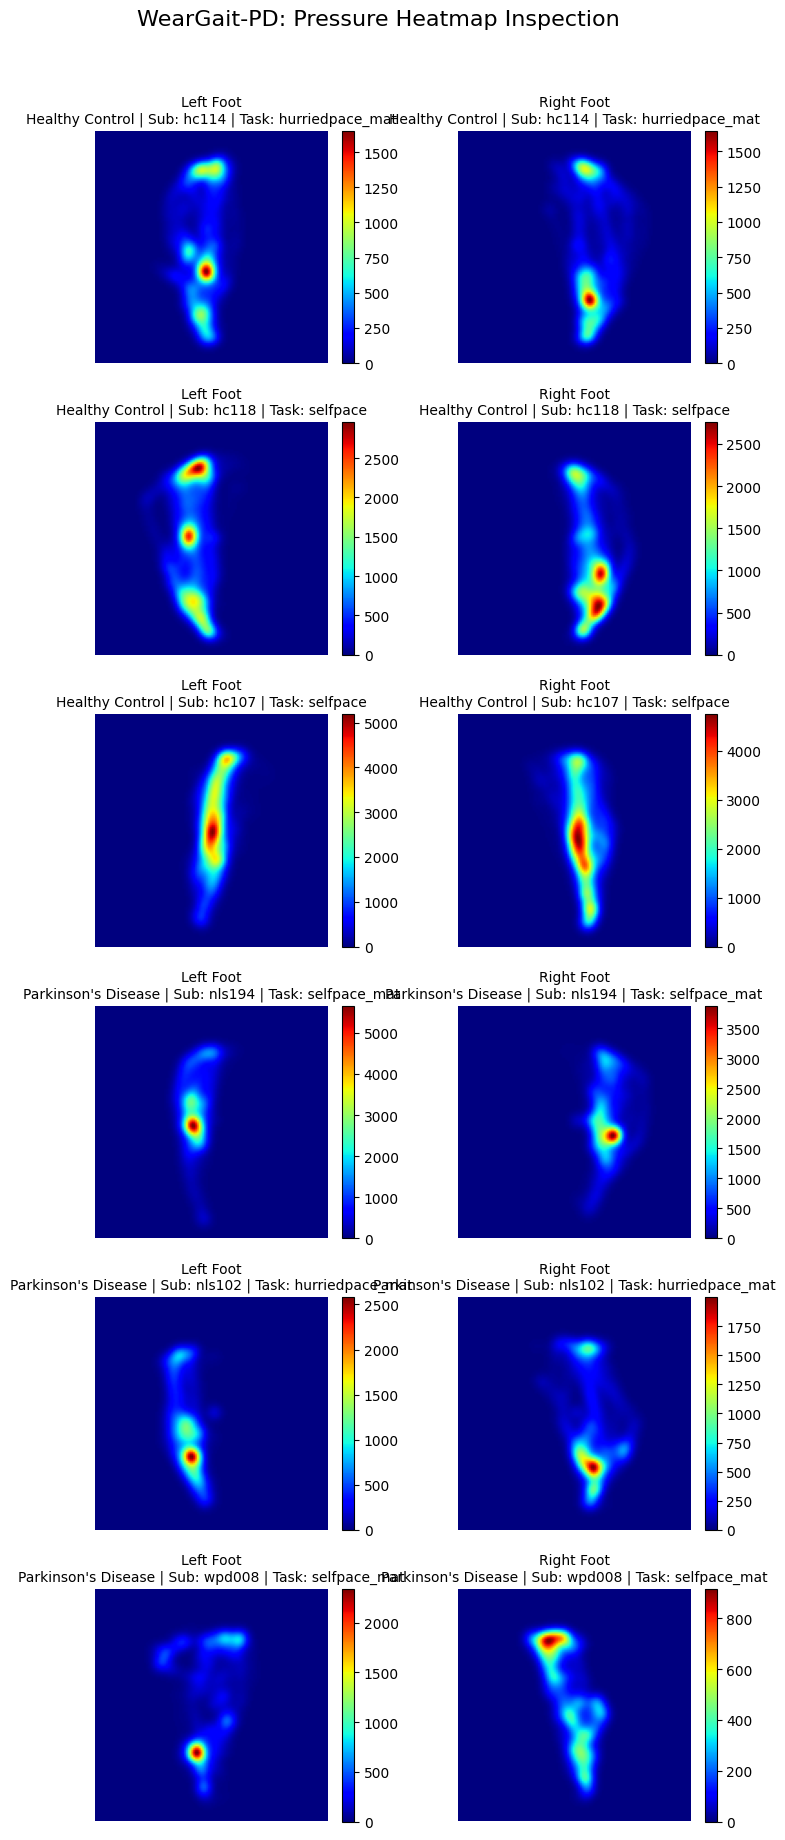

In [7]:
# Visualize the data
import numpy as np
import matplotlib.pyplot as plt

def visualize_heatmaps(npz_filepath="heatmap_dataset.npz", samples_per_class=3):
    # 1. Load the dataset
    print(f"Loading data from {npz_filepath}...")
    data = np.load(npz_filepath, allow_pickle=True)
    X = data['X']           # Shape: (N, 2, 64, 64)
    y = data['y']           # Shape: (N,)
    metadata = data['metadata']
    
    # 2. Separate indices by class (0 = Control, 1 = PD)
    control_idx = np.where(y == 0)[0]
    pd_idx = np.where(y == 1)[0]
    
    # Randomly select a few samples from each class
    selected_control = np.random.choice(control_idx, samples_per_class, replace=False)
    selected_pd = np.random.choice(pd_idx, samples_per_class, replace=False)
    
    selected_indices = np.concatenate([selected_control, selected_pd])
    
    # 3. Plotting
    fig, axes = plt.subplots(nrows=len(selected_indices), ncols=2, figsize=(8, 3 * len(selected_indices)))
    fig.suptitle("WearGait-PD: Pressure Heatmap Inspection", fontsize=16, y=1.02)
    
    for i, idx in enumerate(selected_indices):
        heatmap_l = X[idx, 0, :, :] # Left foot channel
        heatmap_r = X[idx, 1, :, :] # Right foot channel
        
        label_str = "Healthy Control" if y[idx] == 0 else "Parkinson's Disease"
        meta = metadata[idx]
        title = f"{label_str} | Sub: {meta['subject']} | Task: {meta['task']}"
        
        # Left Foot Plot
        im_l = axes[i, 0].imshow(heatmap_l, cmap='jet', origin='lower')
        axes[i, 0].set_title(f"Left Foot\n{title}", fontsize=10)
        axes[i, 0].axis('off')
        
        # Right Foot Plot
        im_r = axes[i, 1].imshow(heatmap_r, cmap='jet', origin='lower')
        axes[i, 1].set_title(f"Right Foot\n{title}", fontsize=10)
        axes[i, 1].axis('off')
        
        # Add colorbars to see the pressure scales
        fig.colorbar(im_l, ax=axes[i, 0], fraction=0.046, pad=0.04)
        fig.colorbar(im_r, ax=axes[i, 1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    
visualize_heatmaps()